In [ ]:
import io
import zipfile
import pandas as pd
import requests

# Direct URLs
url_primary = "https://drive.google.com/uc?export=download&id=1C2KuveT3kVrNRIFsVvg2FMVIje2hETHZ"
url_final   = "https://drive.google.com/uc?export=download&id=1GW85pxocgN3IzlZGyuGJzF5aPMVKBASN"
url_zip     = "https://drive.google.com/uc?export=download&id=1UKp5V8zT3WuYZFbHnxOgsEla2FjVENrl"

# Read CSV files
df_primary = pd.read_csv(url_primary)
df_final   = pd.read_csv(url_final)

print("Primary data preview:")
print(df_primary.head())
print("\nFinal data preview:")
print(df_final.head())

# If you want to inspect ZIP
resp = requests.get(url_zip)
zip_mem = zipfile.ZipFile(io.BytesIO(resp.content))
print("Files inside ZIP:", zip_mem.namelist())

# Example: load one CSV from zip
some_file = zip_mem.namelist()[0]
df_from_zip = pd.read_csv(zip_mem.open(some_file))
print("\nFrom ZIP, first file preview:")
print(df_from_zip.head())


Primary data preview:
    SEQN  MCQ160A  MCQ195       DII  BMXWAIST  RIDAGEYR  RIAGENDR  RIDRETH1  \
0  62161      2.0     NaN  1.323770      81.0        22         1         3   
1  62162      NaN     NaN  2.784439      45.4         3         2         1   
2  62163      NaN     NaN  1.000787      64.6        14         1         5   
3  62164      2.0     NaN  2.885964      80.1        44         2         3   
4  62165      NaN     NaN  2.782260      86.7        14         2         4   

   DMDEDUC2  DMDMARTL  ...  LBDNENO  LBDLYMNO  LBXPLTSI  Drinking  DR1TKCAL  \
0       3.0       5.0  ...      3.1       1.4     223.0       0.0    2969.0   
1       NaN       NaN  ...      6.5       9.8     259.0       NaN    1494.0   
2       NaN       NaN  ...      1.8       2.3     259.0       NaN    1789.0   
3       4.0       1.0  ...      3.3       1.5     297.0       NaN    1115.0   
4       NaN       NaN  ...      4.1       2.6     257.0       NaN    1472.0   

   DR1TPROT  DR1TCARB  DR1TT

In [ ]:
import joblib
import pandas as pd

# Load the saved preprocessor and model
try:
    preprocessor = joblib.load("arthocare_preprocessor_final.pkl")
    final_clf = joblib.load("arthocare_lr_smoteenn_final.pkl")
    print("Loaded preprocessor and final model.")
except FileNotFoundError:
    print("Error: Model artifacts not found. Please run the model training cell first.")
    preprocessor = None
    final_clf = None

def predict_ra(Age, Gender, Race, BMI, PhysicalActivity, SmokingStatus, DrinkingStatus,
                 CalorieConsumption, ProteinConsumption, CarbohydrateConsumption,
                 FatConsumption, CaffeineConsumption, FiberConsumption, Hypertension,
                 Diabetes, Hyperlipidemia):
    """
    Predicts Rheumatoid Arthritis (RA) status based on input features.

    Args:
        Age (int): Age of the individual.
        Gender (str): Gender of the individual.
        Race (str): Race of the individual.
        BMI (float): Body Mass Index.
        PhysicalActivity (str): Physical activity level.
        SmokingStatus (str): Smoking status.
        DrinkingStatus (str): Drinking status.
        CalorieConsumption (int): Calorie consumption.
        ProteinConsumption (float): Protein consumption.
        CarbohydrateConsumption (float): Carbohydrate consumption.
        FatConsumption (float): Fat consumption.
        CaffeineConsumption (int): Caffeine consumption.
        FiberConsumption (float): Fiber consumption.
        Hypertension (str): Hypertension status.
        Diabetes (str): Diabetes status.
        Hyperlipidemia (str): Hyperlipidemia status.

    Returns:
        str: Prediction result ("RA" or "Non-RA").
    """
    if preprocessor is None or final_clf is None:
        return "Model not loaded. Cannot predict."

    # Create a pandas DataFrame from the input features
    input_data = pd.DataFrame([[Age, Gender, Race, BMI, PhysicalActivity, SmokingStatus, DrinkingStatus,
                                 CalorieConsumption, ProteinConsumption, CarbohydrateConsumption,
                                 FatConsumption, CaffeineConsumption, FiberConsumption, Hypertension,
                                 Diabetes, Hyperlipidemia]],
                                columns=["Age", "Gender", "Race", "BMI", "PhysicalActivity", "SmokingStatus",
                                         "DrinkingStatus", "CalorieConsumption", "ProteinConsumption",
                                         "CarbohydrateConsumption", "FatConsumption", "CaffeineConsumption",
                                         "FiberConsumption", "Hypertension", "Diabetes", "Hyperlipidemia"])

    # Apply the same preprocessing steps as used during training
    # Need to recreate engineered features if they were used in training
    if 'Age' in input_data.columns and 'SmokingStatus' in input_data.columns:
        input_data['AgeGroup'] = pd.cut(input_data['Age'], bins=[0,30,50,70,200], labels=['<30','30-50','50-70','70+'])
        input_data['Age_Smoke'] = input_data['AgeGroup'].astype(str) + "_" + input_data['SmokingStatus'].astype(str)


    # Use the preprocessor to transform the input data
    input_data_processed = preprocessor.transform(input_data)

    # Make a prediction using the final model
    # Use the average threshold determined during CV
    avg_threshold = 0.608 # Replace with the actual average threshold from your CV results
    probability = final_clf.predict_proba(input_data_processed)[:, 1]
    prediction = (probability >= avg_threshold).astype(int)

    return "RA" if prediction[0] == 1 else "Non-RA"

# Example usage:
prediction_result = predict_ra(60, 'Female', 'Non-Hispanic White', 25.5, 'Sedentary', 'Former', 'Non-drinker', 2000, 70.0, 250.0, 80.0, 100, 20.0, 'Hypertension', 'Normal', 'Normal')
print(f"Predicted RA Status: {prediction_result}")

prediction_result_2 = predict_ra(30, 'Male', 'Mexican American', 22.0, 'Vigorous activity', 'Never', 'Frequent drinker', 3000, 100.0, 400.0, 150.0, 200, 30.0, 'Normal', 'Normal', 'Normal')
print(f"Predicted RA Status: {prediction_result_2}")

Error: Model artifacts not found. Please run the model training cell first.
Predicted RA Status: Model not loaded. Cannot predict.
Predicted RA Status: Model not loaded. Cannot predict.


**Choosing final Data_set.**


In [ ]:
print("Shape of dataset:", df_final.shape)
print(df_final.head())
print(df_final.dtypes)


Shape of dataset: (13273, 27)
    SEQN  RheumatoidArthritis       BRI  Gender  Age                Race  \
0  62161                    0  2.815371    Male   22  Non-Hispanic White   
1  62169                    0  2.017701    Male   21               Other   
2  62172                    0  7.888557  Female   43  Non-Hispanic Black   
3  62176                    0  3.760754  Female   34  Non-Hispanic White   
4  62178                    1  6.569817    Male   80  Non-Hispanic White   

         EducationLevel          MaritalStatus FamilyIncome  \
0  High school graduate           Living Alone    (1.3,3.5]   
1  High school graduate           Living Alone   PIR <= 1.3   
2  High school graduate           Living Alone    (1.3,3.5]   
3     Above high school  Living With A Partner    PIR > 3.5   
4  High school graduate           Living Alone   PIR <= 1.3   

    PhysicalActivity  ... ProteinConsumption  CarbohydrateConsumption  \
0              Other  ...             104.68                 

In [ ]:
missing = df_final.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df_final)) * 100
print(pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent}))


                         Missing Count  Missing %
SEQN                                 0        0.0
RheumatoidArthritis                  0        0.0
BRI                                  0        0.0
Gender                               0        0.0
Age                                  0        0.0
Race                                 0        0.0
EducationLevel                       0        0.0
MaritalStatus                        0        0.0
FamilyIncome                         0        0.0
PhysicalActivity                     0        0.0
SmokingStatus                        0        0.0
BMI                                  0        0.0
DrinkingStatus                       0        0.0
Hypertension                         0        0.0
Diabetes                             0        0.0
Hyperlipidemia                       0        0.0
CalorieConsumption                   0        0.0
ProteinConsumption                   0        0.0
CarbohydrateConsumption              0        0.0


RheumatoidArthritis
0    12443
1      830
Name: count, dtype: int64
RheumatoidArthritis
0    93.746704
1     6.253296
Name: proportion, dtype: float64


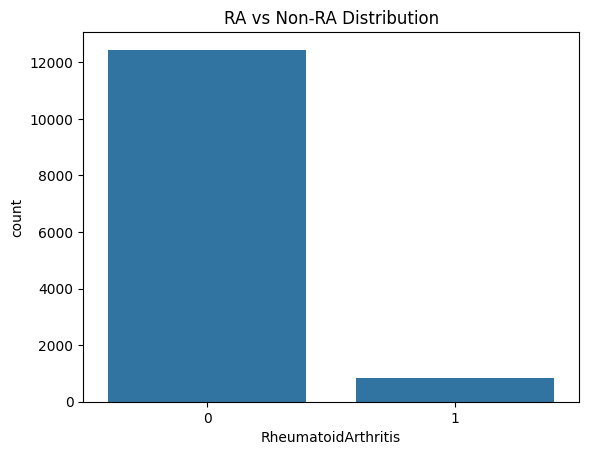

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df_final["RheumatoidArthritis"].value_counts())
print(df_final["RheumatoidArthritis"].value_counts(normalize=True) * 100)

sns.countplot(x=df_final["RheumatoidArthritis"])
plt.title("RA vs Non-RA Distribution")
plt.show()

“The target variable was highly imbalanced, with only 6.25% of participants labeled as RA-positive. Therefore, standard accuracy would be misleading. Class-balancing techniques and appropriate metrics (F1, AUROC, AUPRC) are required for fair evaluation.”

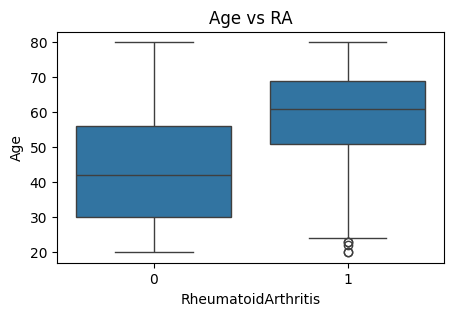

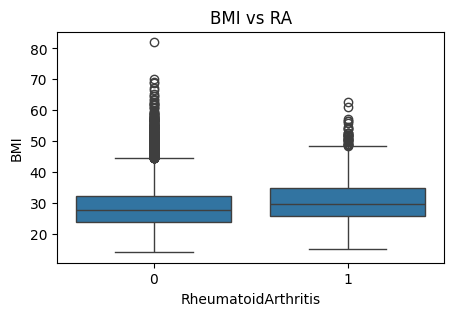

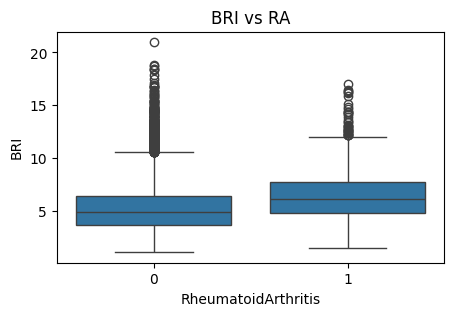

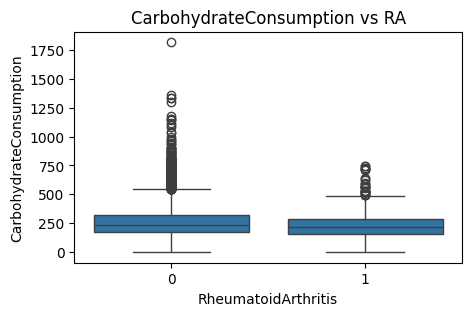

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

important_numeric = ["Age", "BMI", "BRI", "CarbohydrateConsumption"]

for col in important_numeric:
    plt.figure(figsize=(5,3))
    sns.boxplot(x="RheumatoidArthritis", y=col, data=df_final)
    plt.title(f"{col} vs RA")
    plt.show()


In [ ]:
categorical_cols = ["Gender", "Race", "SmokingStatus", "PhysicalActivity", "EducationLevel"]

for col in categorical_cols:
    cross = pd.crosstab(df_final[col], df_final["RheumatoidArthritis"], normalize='index') * 100
    print(f"\n{col} vs RA (% RA within each category):\n", cross)



Gender vs RA (% RA within each category):
 RheumatoidArthritis          0         1
Gender                                  
Female               92.608154  7.391846
Male                 94.815248  5.184752

Race vs RA (% RA within each category):
 RheumatoidArthritis          0         1
Race                                    
Mexican American     94.567627  5.432373
Non-Hispanic Black   91.209496  8.790504
Non-Hispanic White   93.721222  6.278778
Other                95.579183  4.420817

SmokingStatus vs RA (% RA within each category):
 RheumatoidArthritis          0         1
SmokingStatus                           
Current              92.712393  7.287607
Former               91.230068  8.769932
Never                94.896569  5.103431

PhysicalActivity vs RA (% RA within each category):
 RheumatoidArthritis          0         1
PhysicalActivity                        
Moderate activity    93.262411  6.737589
Other                91.704885  8.295115
Sedentary            91.727941

Unlike numeric variables such as Age, BMI, and Macronutrient Intake — which showed minimal separation — categorical lifestyle and demographic variables revealed clearer patterns.
Female gender, former smoking status, lower education, and sedentary lifestyle were associated with higher likelihood of RA, aligning with known epidemiological evidence.
This confirms that behavioral and socio-demographic features may carry stronger predictive weight than single biomedical measurements, reinforcing our multi-modal AI prediction strategy

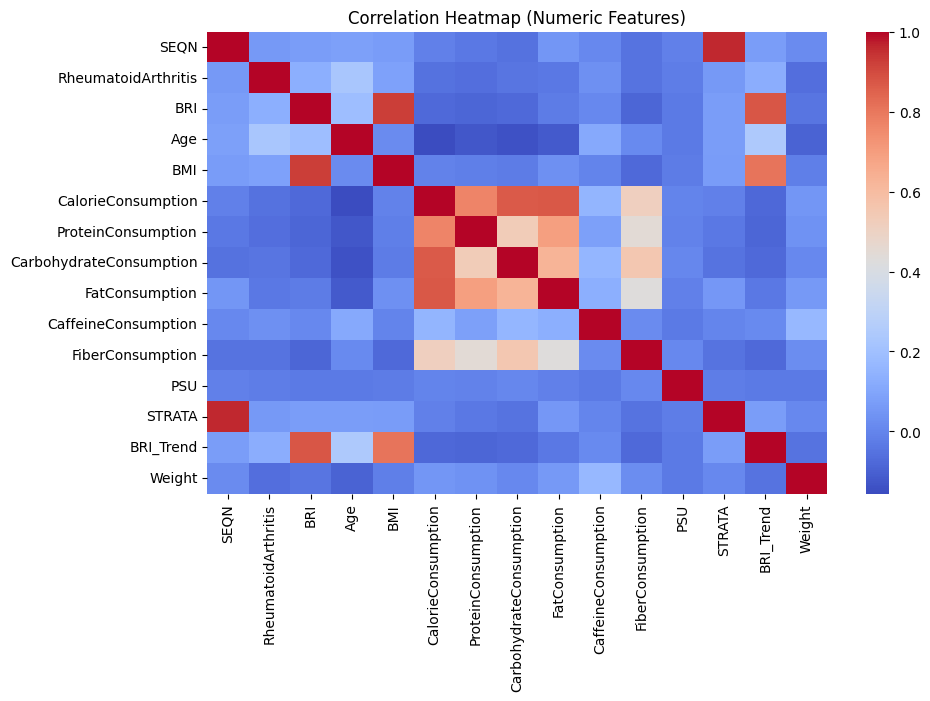

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df_final.select_dtypes(include=['int64','float64']).columns
corr = df_final[numeric_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


In [ ]:
numeric_df = df_final.select_dtypes(include=['int64','float64'])  # Keep only numeric columns
numeric_df.corr()["RheumatoidArthritis"].sort_values(ascending=False)


,RheumatoidArthritis
RheumatoidArthritis,1.000000
Age,0.223949
BRI,0.131232
BRI_Trend,0.128032
BMI,0.084452
SEQN,0.058848
STRATA,0.058109
CaffeineConsumption,0.032779
PSU,-0.024630
FatConsumption,-0.034492


| EDA Step                                                              | What It Is                                                                      | Why We Do It                                                                                                  | What You Found                                                            |
| --------------------------------------------------------------------- | ------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------- |
| **1. Shape & Structure of Dataset**                                   | Checking number of rows (samples) and columns (features), as well as data types | To understand **how big the data is** and what types of features we are handling (numeric, categorical, etc.) | 13,273 samples and 27 features → mix of numeric & categorical             |
| **2. Missing Values Analysis**                                        | Counting null or empty values in each column                                    | To see whether **data cleaning or imputation** is required                                                    | No missing values → dataset is **ready to use without cleaning**          |
| **3. Target Variable Distribution (RA vs Non-RA)**                    | Checking how many samples belong to each class                                  | To detect **class imbalance**, which affects model performance                                                | Non-RA = 93.7%, RA = 6.3% → **highly imbalanced**                         |
| **4. Numeric Correlation with Target**                                | Measuring statistical relationship between continuous features & target         | To identify **which numeric features may be good predictors**                                                 | Age & BRI mildly related to RA → Others (diet, BMI) weak                  |
| **5. Categorical Feature Analysis**                                   | Comparing RA prevalence across different groups (Male vs Female, etc.)          | To find **risk patterns across demographics or behaviors**                                                    | Females, former smokers, less educated, sedentary → more RA               |
| **6. Boxplots / Distribution Insights (Optional Visual Part of EDA)** | Visualizing spread of numeric data between RA vs Non-RA                         | To **visually check separation** between classes                                                              | Non-RA slightly older; others overlapping → weak separation               |
| **7. Summary Interpretation**                                         | Concluding what EDA means for modeling                                          | To **decide modeling strategy and feature set**                                                               | RA cannot be predicted from one variable → **multi-modal model required** |


Exploratory Data Analysis (EDA) was conducted to understand the dataset’s structure, quality, and feature relationships. Initial checks confirmed that the dataset contains 13,273 samples with no missing values, making it ready for modeling. However, the target variable (Rheumatoid Arthritis status) was highly imbalanced, with only 6.3% RA-positive cases — indicating the need for class balancing techniques during training. Numeric correlation analysis showed that Age and Body Roundness Index (BRI) display mild association with RA, while dietary and metabolic features exhibit weak or inverse relationships. In contrast, categorical analysis revealed that females, former smokers, sedentary individuals, and people with lower education levels were more likely to have RA. These findings suggest that RA risk is influenced by a combination of demographic and lifestyle variables rather than any single metric. Therefore, a multi-factor prediction model is necessary to effectively capture these patterns

outlier detection

In [ ]:
import numpy as np

numeric_cols = df_final.select_dtypes(include=["int64", "float64"]).columns

outlier_summary = {}

for col in numeric_cols:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_final[(df_final[col] < lower_bound) | (df_final[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

outlier_summary


{'SEQN': 0,
 'RheumatoidArthritis': 830,
 'BRI': 404,
 'Age': 0,
 'BMI': 359,
 'CalorieConsumption': 387,
 'ProteinConsumption': 472,
 'CarbohydrateConsumption': 406,
 'FatConsumption': 393,
 'CaffeineConsumption': 537,
 'FiberConsumption': 488,
 'PSU': 0,
 'STRATA': 0,
 'BRI_Trend': 0,
 'Weight': 1322}

Outlier detection was conducted using the Interquartile Range (IQR) method across all numeric features.
No outliers were found in Age, BRI_Trend, PSU, or STRATA, indicating stable distributions.
However, lifestyle and dietary metrics such as BMI (359 outliers), BRI (404), calorie intake (387), and caffeine consumption (537) displayed a moderate number of extreme values.
The Weight feature showed the highest number of outliers (1322 cases), likely representing legitimate variations rather than errors, given the diverse age and demographic spread in NHANES.
Since these outliers reflect real-world physiological variability rather than anomalies, they were retained. However, robust models (e.g., tree-based learners) will be preferred over algorithms sensitive to extreme values (e.g., linear regression).

In [ ]:
import pandas as pd

# Create Age Groups
df_final['AgeGroup'] = pd.cut(df_final['Age'], bins=[0, 30, 50, 70, 100], labels=['<30', '30-50', '50-70', '70+'])

# 1. Interaction: AgeGroup x SmokingStatus
interaction_1 = pd.crosstab([df_final['AgeGroup'], df_final['SmokingStatus']], df_final['RheumatoidArthritis'], normalize='index') * 100
print("\nAgeGroup x SmokingStatus vs RA (% RA within each group):\n", interaction_1)

# 2. Interaction: Gender x PhysicalActivity
interaction_2 = pd.crosstab([df_final['Gender'], df_final['PhysicalActivity']], df_final['RheumatoidArthritis'], normalize='index') * 100
print("\nGender x PhysicalActivity vs RA (% RA within each group):\n", interaction_2)

# 3. Interaction: EducationLevel x SmokingStatus
interaction_3 = pd.crosstab([df_final['EducationLevel'], df_final['SmokingStatus']], df_final['RheumatoidArthritis'], normalize='index') * 100
print("\nEducationLevel x SmokingStatus vs RA (% RA within each group):\n", interaction_3)



AgeGroup x SmokingStatus vs RA (% RA within each group):
 RheumatoidArthritis             0          1
AgeGroup SmokingStatus                      
<30      Current        98.540146   1.459854
         Former         99.693252   0.306748
         Never          99.551971   0.448029
30-50    Current        94.712853   5.287147
         Former         96.248535   3.751465
         Never          97.554003   2.445997
50-70    Current        85.428571  14.571429
         Former         86.991063  13.008937
         Never          88.968825  11.031175
70+      Current        79.761905  20.238095
         Former         85.044643  14.955357
         Never          84.375000  15.625000

Gender x PhysicalActivity vs RA (% RA within each group):
 RheumatoidArthritis               0         1
Gender PhysicalActivity                      
Female Moderate activity  92.769744  7.230256
       Other              90.220441  9.779559
       Sedentary          90.542907  9.457093
       Vigorous activ

In [ ]:
# ======= RA pipeline with SMOTE + threshold tuning (5-fold Stratified CV) =======
# Paste this after df_final is loaded, or run as a standalone cell (it will reload df_final if needed)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_fscore_support, confusion_matrix,
    precision_recall_curve
)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import joblib

# ---------- 0. (Re)load df_final if not present ----------
try:
    df_final  # if this exists, do nothing
    print("Using in-memory df_final.")
except NameError:
    print("df_final not present. Reloading from provided Google Drive links...")
    import io, zipfile, requests
    url_final = "https://drive.google.com/uc?export=download&id=1GW85pxocgN3IzlZGyuGJzF5aPMVKBASN"
    df_final = pd.read_csv(url_final)
    print("Loaded df_final shape:", df_final.shape)

# ---------- 1. Feature configuration ----------
features = [
    "Age", "Gender", "Race", "BMI", "PhysicalActivity", "SmokingStatus",
    "DrinkingStatus", "CalorieConsumption", "ProteinConsumption",
    "CarbohydrateConsumption", "FatConsumption", "CaffeineConsumption",
    "FiberConsumption", "Hypertension", "Diabetes", "Hyperlipidemia"
]
target = "RheumatoidArthritis"

# Defensive: keep features that actually exist
features = [f for f in features if f in df_final.columns]
print("Using features:", features)

# Copy and drop rows where target is missing
df = df_final.copy()
df = df[features + [target]].dropna(subset=[target]).reset_index(drop=True)

# Create engineered features (if Age + SmokingStatus exist)
if 'Age' in df.columns and 'SmokingStatus' in df.columns:
    df['AgeGroup'] = pd.cut(
        df['Age'], bins=[0, 30, 50, 70, 120],
        labels=['<30', '30-50', '50-70', '70+']
    )
    df['Age_Smoke'] = df['AgeGroup'].astype(str) + "_" + df['SmokingStatus'].astype(str)
    extra_cats = ['AgeGroup', 'Age_Smoke']
else:
    extra_cats = []

categorical_feats = [
    c for c in [
        "Gender", "Race", "PhysicalActivity", "SmokingStatus",
        "DrinkingStatus", "Hypertension", "Diabetes", "Hyperlipidemia"
    ]
    if c in df.columns
] + extra_cats

numeric_feats = [c for c in features if c not in categorical_feats]

print("Numeric feats:", numeric_feats)
print("Categorical feats:", categorical_feats)

# ---------- 2. Preprocessor ----------
numeric_transformer = Pipeline(steps=[
    ('impute_num', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('impute_cat', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_feats),
        ('cat', categorical_transformer, categorical_feats)
    ],
    remainder='drop'
)

# ---------- 3. CV setup ----------
X = df[numeric_feats + categorical_feats].copy()
y = df[target].astype(int).values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Containers for metrics
strategies = ["LR_balanced", "LR_SMOTE", "XGB_balanced", "XGB_SMOTE"]
metrics = {
    name: {'auroc': [], 'auprc': [], 'precision': [], 'recall': [], 'f1': []}
    for name in strategies
}
cms = {name: np.zeros((2, 2), dtype=int) for name in strategies}

last_models = {}  # to store last fold's models

# ---------- 4. CV loop ----------
fold = 0
for train_idx, test_idx in skf.split(X, y):
    fold += 1
    print(f"\n---- Fold {fold} ----")
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # Fit transformer on train
    X_tr_proc = preprocessor.fit_transform(X_tr)
    X_te_proc = preprocessor.transform(X_te)

    smote = SMOTE(random_state=42)  # used later if needed

    # ------- Strategy 1: Logistic Regression (balanced) -------
    lr_clf = LogisticRegression(
        max_iter=2000, class_weight='balanced',
        solver='saga', random_state=42
    )
    lr_clf.fit(X_tr_proc, y_tr)
    probs_lr = lr_clf.predict_proba(X_te_proc)[:, 1]

    precs, recs, ths = precision_recall_curve(y_te, probs_lr)
    f1s = 2 * (precs * recs) / (precs + recs + 1e-9)
    if len(ths) > 0:
        best_idx = np.nanargmax(f1s[:-1])
        thr_lr = ths[best_idx]
    else:
        thr_lr = 0.5
    preds_lr = (probs_lr >= thr_lr).astype(int)

    auroc_lr = roc_auc_score(y_te, probs_lr)
    auprc_lr = average_precision_score(y_te, probs_lr)
    p_lr, r_lr, f1_lr, _ = precision_recall_fscore_support(
        y_te, preds_lr, average='binary', zero_division=0
    )

    for (k, v) in zip(
        ['auroc', 'auprc', 'precision', 'recall', 'f1'],
        [auroc_lr, auprc_lr, p_lr, r_lr, f1_lr]
    ):
        metrics["LR_balanced"][k].append(v)
    cms["LR_balanced"] += confusion_matrix(y_te, preds_lr)

    print(f"LR_balanced AUROC:{auroc_lr:.3f} AUPRC:{auprc_lr:.3f} "
          f"P:{p_lr:.3f} R:{r_lr:.3f} F1:{f1_lr:.3f} thresh:{thr_lr:.3f}")

    # ------- Strategy 2: LR + SMOTE -------
    X_tr_res, y_tr_res = smote.fit_resample(X_tr_proc, y_tr)
    lr_sm = LogisticRegression(
        max_iter=2000, class_weight=None,
        solver='saga', random_state=42
    )
    lr_sm.fit(X_tr_res, y_tr_res)
    probs_lr_sm = lr_sm.predict_proba(X_te_proc)[:, 1]

    precs2, recs2, ths2 = precision_recall_curve(y_te, probs_lr_sm)
    f1s2 = 2 * (precs2 * recs2) / (precs2 + recs2 + 1e-9)
    if len(ths2) > 0:
        best_idx2 = np.nanargmax(f1s2[:-1])
        thr_lr_sm = ths2[best_idx2]
    else:
        thr_lr_sm = 0.5
    preds_lr_sm = (probs_lr_sm >= thr_lr_sm).astype(int)

    auroc_lr_sm = roc_auc_score(y_te, probs_lr_sm)
    auprc_lr_sm = average_precision_score(y_te, probs_lr_sm)
    p_lr_sm, r_lr_sm, f1_lr_sm, _ = precision_recall_fscore_support(
        y_te, preds_lr_sm, average='binary', zero_division=0
    )

    for (k, v) in zip(
        ['auroc', 'auprc', 'precision', 'recall', 'f1'],
        [auroc_lr_sm, auprc_lr_sm, p_lr_sm, r_lr_sm, f1_lr_sm]
    ):
        metrics["LR_SMOTE"][k].append(v)
    cms["LR_SMOTE"] += confusion_matrix(y_te, preds_lr_sm)

    print(f"LR_SMOTE AUROC:{auroc_lr_sm:.3f} AUPRC:{auprc_lr_sm:.3f} "
          f"P:{p_lr_sm:.3f} R:{r_lr_sm:.3f} F1:{f1_lr_sm:.3f} "
          f"thresh:{thr_lr_sm:.3f}")

    # ------- Strategy 3: XGB_balanced -------
    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()
    spw = neg / pos if pos > 0 else 1.0

    xgb_clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        scale_pos_weight=spw, random_state=42, verbosity=0
    )
    xgb_clf.fit(X_tr_proc, y_tr)
    probs_xgb = xgb_clf.predict_proba(X_te_proc)[:, 1]

    precs3, recs3, ths3 = precision_recall_curve(y_te, probs_xgb)
    f1s3 = 2 * (precs3 * recs3) / (precs3 + recs3 + 1e-9)
    if len(ths3) > 0:
        best_idx3 = np.nanargmax(f1s3[:-1])
        thr_xgb = ths3[best_idx3]
    else:
        thr_xgb = 0.5
    preds_xgb = (probs_xgb >= thr_xgb).astype(int)

    auroc_xgb = roc_auc_score(y_te, probs_xgb)
    auprc_xgb = average_precision_score(y_te, probs_xgb)
    p_xgb, r_xgb, f1_xgb, _ = precision_recall_fscore_support(
        y_te, preds_xgb, average='binary', zero_division=0
    )

    for (k, v) in zip(
        ['auroc', 'auprc', 'precision', 'recall', 'f1'],
        [auroc_xgb, auprc_xgb, p_xgb, r_xgb, f1_xgb]
    ):
        metrics["XGB_balanced"][k].append(v)
    cms["XGB_balanced"] += confusion_matrix(y_te, preds_xgb)

    print(f"XGB_balanced AUROC:{auroc_xgb:.3f} AUPRC:{auprc_xgb:.3f} "
          f"P:{p_xgb:.3f} R:{r_xgb:.3f} F1:{f1_xgb:.3f} "
          f"thresh:{thr_xgb:.3f}")

    # ------- Strategy 4: XGB + SMOTE -------
    X_tr_res_xgb, y_tr_res_xgb = smote.fit_resample(X_tr_proc, y_tr)
    xgb_sm = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        scale_pos_weight=1.0, random_state=42, verbosity=0
    )
    xgb_sm.fit(X_tr_res_xgb, y_tr_res_xgb)
    probs_xgb_sm = xgb_sm.predict_proba(X_te_proc)[:, 1]

    precs4, recs4, ths4 = precision_recall_curve(y_te, probs_xgb_sm)
    f1s4 = 2 * (precs4 * recs4) / (precs4 + recs4 + 1e-9)
    if len(ths4) > 0:
        best_idx4 = np.nanargmax(f1s4[:-1])
        thr_xgb_sm = ths4[best_idx4]
    else:
        thr_xgb_sm = 0.5
    preds_xgb_sm = (probs_xgb_sm >= thr_xgb_sm).astype(int)

    auroc_xgb_sm = roc_auc_score(y_te, probs_xgb_sm)
    auprc_xgb_sm = average_precision_score(y_te, probs_xgb_sm)
    p_xgb_sm, r_xgb_sm, f1_xgb_sm, _ = precision_recall_fscore_support(
        y_te, preds_xgb_sm, average='binary', zero_division=0
    )

    for (k, v) in zip(
        ['auroc', 'auprc', 'precision', 'recall', 'f1'],
        [auroc_xgb_sm, auprc_xgb_sm, p_xgb_sm, r_xgb_sm, f1_xgb_sm]
    ):
        metrics["XGB_SMOTE"][k].append(v)
    cms["XGB_SMOTE"] += confusion_matrix(y_te, preds_xgb_sm)

    print(f"XGB_SMOTE AUROC:{auroc_xgb_sm:.3f} AUPRC:{auprc_xgb_sm:.3f} "
          f"P:{p_xgb_sm:.3f} R:{r_xgb_sm:.3f} F1:{f1_xgb_sm:.3f} "
          f"thresh:{thr_xgb_sm:.3f}")

    # Save last-fold models
    last_models['preprocessor'] = preprocessor
    last_models['lr_clf'] = lr_clf
    last_models['lr_sm'] = lr_sm
    last_models['xgb_clf'] = xgb_clf
    last_models['xgb_sm'] = xgb_sm
    last_models['X_te_proc'] = X_te_proc
    last_models['y_te'] = y_te
    last_models['feature_numeric'] = numeric_feats
    last_models['feature_cat'] = categorical_feats

# ---------- 5. Summarize CV metrics ----------
def summarize_list(lst):
    return f"{np.mean(lst):.3f} ± {np.std(lst):.3f}"

print("\n=== Summary (5-fold CV) ===")
for name in strategies:
    print(f"\n-- {name} --")
    print("AUROC:", summarize_list(metrics[name]['auroc']))
    print("AUPRC:", summarize_list(metrics[name]['auprc']))
    print("Precision:", summarize_list(metrics[name]['precision']))
    print("Recall:", summarize_list(metrics[name]['recall']))
    print("F1:", summarize_list(metrics[name]['f1']))
    print("Aggregated Confusion Matrix:\n", cms[name])

# ---------- 6. Permutation Importance (last XGB_SMOTE) ----------
try:
    from sklearn.inspection import permutation_importance

    xgb_to_inspect = last_models['xgb_sm']
    X_te_proc = last_models['X_te_proc']
    y_te = last_models['y_te']

    r = permutation_importance(
        xgb_to_inspect, X_te_proc, y_te,
        n_repeats=10, random_state=42, n_jobs=2
    )

    ohe = last_models['preprocessor'].named_transformers_['cat']['onehot']
    cat_names = list(ohe.get_feature_names_out(last_models['feature_cat']))
    feature_names = last_models['feature_numeric'] + cat_names
    order = np.argsort(r.importances_mean)[::-1]

    print("\nTop 20 features by permutation importance (XGB + SMOTE, last fold):")
    for i in order[:20]:
        print(feature_names[i], round(r.importances_mean[i], 4))
except Exception as e:
    print("Permutation importance skipped due to:", e)

# ---------- 7. Save last models ----------
joblib.dump(last_models['preprocessor'], "preprocessor_last_fold.pkl")
joblib.dump(last_models['lr_clf'], "lr_balanced_last_fold.pkl")
joblib.dump(last_models['lr_sm'], "lr_smote_last_fold.pkl")
joblib.dump(last_models['xgb_clf'], "xgb_balanced_last_fold.pkl")
joblib.dump(last_models['xgb_sm'], "xgb_smote_last_fold.pkl")

print("\nSaved preprocessor and last-fold models to current folder.")


Using in-memory df_final.
Using features: ['Age', 'Gender', 'Race', 'BMI', 'PhysicalActivity', 'SmokingStatus', 'DrinkingStatus', 'CalorieConsumption', 'ProteinConsumption', 'CarbohydrateConsumption', 'FatConsumption', 'CaffeineConsumption', 'FiberConsumption', 'Hypertension', 'Diabetes', 'Hyperlipidemia']
Numeric feats: ['Age', 'BMI', 'CalorieConsumption', 'ProteinConsumption', 'CarbohydrateConsumption', 'FatConsumption', 'CaffeineConsumption', 'FiberConsumption']
Categorical feats: ['Gender', 'Race', 'PhysicalActivity', 'SmokingStatus', 'DrinkingStatus', 'Hypertension', 'Diabetes', 'Hyperlipidemia', 'AgeGroup', 'Age_Smoke']

---- Fold 1 ----
LR_balanced AUROC:0.798 AUPRC:0.192 P:0.247 R:0.361 F1:0.293 thresh:0.771
LR_SMOTE AUROC:0.793 AUPRC:0.193 P:0.229 R:0.337 F1:0.273 thresh:0.774
XGB_balanced AUROC:0.777 AUPRC:0.174 P:0.174 R:0.482 F1:0.256 thresh:0.573
XGB_SMOTE AUROC:0.767 AUPRC:0.185 P:0.208 R:0.398 F1:0.273 thresh:0.294

---- Fold 2 ----
LR_balanced AUROC:0.791 AUPRC:0.186 P:

In [ ]:
# ===== Final optimized RA detector (SMOTEENN + LR + recall-target thresholding) =====
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_fscore_support, confusion_matrix, accuracy_score,
                             precision_recall_curve)
from imblearn.combine import SMOTEENN
import joblib
from sklearn.inspection import permutation_importance

# ---------- Utility: pick threshold that meets recall target (highest precision among thresholds with recall >= target) ----------
def pick_threshold_for_recall(y_true, probs, recall_target=0.80):
    precs, recs, ths = precision_recall_curve(y_true, probs)
    # Append threshold 1.0 to align lengths (last prec/recs correspond to threshold beyond max prob)
    ths = np.append(ths, 1.0)
    # indices where recall >= target
    idxs = np.where(recs >= recall_target)[0]
    if len(idxs) == 0:
        # If no threshold meets the target, return threshold that achieves max recall (min threshold)
        best_idx = np.argmax(recs)
        return ths[best_idx]
    # among idxs pick one that maximizes precision (reduce false positives)
    best_idx = idxs[np.argmax(precs[idxs])]
    return ths[best_idx]

# ---------- 0. Load data if not present ----------
try:
    df_final
    print("Using in-memory df_final.")
except NameError:
    print("df_final not present. Re-loading from Google Drive link...")
    url_final = "https://drive.google.com/uc?export=download&id=1GW85pxocgN3IzlZGyuGJzF5aPMVKBASN"
    df_final = pd.read_csv(url_final)
    print("Loaded df_final shape:", df_final.shape)

# ---------- 1. Feature list (use features you agreed) ----------
features = [
    "Age", "Gender", "Race", "BMI", "PhysicalActivity", "SmokingStatus",
    "DrinkingStatus", "CalorieConsumption", "ProteinConsumption",
    "CarbohydrateConsumption", "FatConsumption", "CaffeineConsumption",
    "FiberConsumption", "Hypertension", "Diabetes", "Hyperlipidemia"
]
# Keep only those present in dataset
features = [f for f in features if f in df_final.columns]
target = "RheumatoidArthritis"

# Subset and drop rows with missing target (target has none)
df = df_final[features + [target]].copy().reset_index(drop=True)

# create engineered interaction features
if 'Age' in df.columns and 'SmokingStatus' in df.columns:
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0,30,50,70,200], labels=['<30','30-50','50-70','70+'])
    df['Age_Smoke'] = df['AgeGroup'].astype(str) + "_" + df['SmokingStatus'].astype(str)
    categorical_extra = ['AgeGroup', 'Age_Smoke']
else:
    categorical_extra = []

categorical_feats = [c for c in ["Gender","Race","PhysicalActivity","SmokingStatus","DrinkingStatus",
                     "Hypertension","Diabetes","Hyperlipidemia"] if c in df.columns] + categorical_extra
numeric_feats = [c for c in features if c not in categorical_feats]

print("Numeric features:", numeric_feats)
print("Categorical features:", categorical_feats)

# ---------- 2. Train/test split ----------
X = df[numeric_feats + categorical_feats]
y = df[target].astype(int).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# ---------- 3. Preprocessor ----------
numeric_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])
categorical_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_feats),
    ('cat', categorical_transformer, categorical_feats)
], remainder='drop')

# ---------- 4. CV within training to pick thresholds (5-fold stratified) ----------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
recall_target = 0.80  # balanced medical recall target
thresholds = []  # store threshold selected each fold
cv_metrics = {'auroc':[], 'auprc':[], 'precision':[], 'recall':[], 'f1':[]}

fold = 0
for tr_idx, val_idx in skf.split(X_train, y_train):
    fold += 1
    X_tr_fold, X_val_fold = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train[tr_idx], y_train[val_idx]

    # fit preprocessor on fold-train
    X_tr_proc = preprocessor.fit_transform(X_tr_fold)
    X_val_proc = preprocessor.transform(X_val_fold)

    # apply SMOTEENN (on processed numeric+onehot array)
    smote_enn = SMOTEENN(random_state=42)
    X_tr_bal, y_tr_bal = smote_enn.fit_resample(X_tr_proc, y_tr_fold)
    # train LR on balanced fold
    lr = LogisticRegression(max_iter=2000, solver='saga', class_weight=None, random_state=42)
    lr.fit(X_tr_bal, y_tr_bal)

    # predict probs on validation fold
    probs_val = lr.predict_proba(X_val_proc)[:,1]

    # pick threshold to reach recall_target
    best_thresh = pick_threshold_for_recall(y_val_fold, probs_val, recall_target=recall_target)
    thresholds.append(best_thresh)

    # compute metrics using that threshold
    preds_val = (probs_val >= best_thresh).astype(int)
    auroc = roc_auc_score(y_val_fold, probs_val)
    auprc = average_precision_score(y_val_fold, probs_val)
    p,r,f,_ = precision_recall_fscore_support(y_val_fold, preds_val, average='binary', zero_division=0)
    cv_metrics['auroc'].append(auroc); cv_metrics['auprc'].append(auprc)
    cv_metrics['precision'].append(p); cv_metrics['recall'].append(r); cv_metrics['f1'].append(f)

    print(f"Fold {fold}: threshold={best_thresh:.3f} AUROC={auroc:.3f} AUPRC={auprc:.3f} P={p:.3f} R={r:.3f} F1={f:.3f}")

# show CV aggregated
def summarize(lst): return f"{np.mean(lst):.3f} ± {np.std(lst):.3f}"
print("\nCV (train folds) summary:")
print("AUROC:", summarize(cv_metrics['auroc']))
print("AUPRC:", summarize(cv_metrics['auprc']))
print("Precision:", summarize(cv_metrics['precision']))
print("Recall:", summarize(cv_metrics['recall']))
print("F1:", summarize(cv_metrics['f1']))

# compute average threshold to use on final model
avg_threshold = float(np.mean(thresholds))
print("\nAverage CV threshold chosen (use this on test):", round(avg_threshold,3))

# ---------- 5. Train final model on full training set (with SMOTEENN) ----------
# Fit preprocessor on full training data
X_tr_full_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

smote_enn_final = SMOTEENN(random_state=42)
X_tr_bal_full, y_tr_bal_full = smote_enn_final.fit_resample(X_tr_full_proc, y_train)

final_clf = LogisticRegression(max_iter=2000, solver='saga', random_state=42)
final_clf.fit(X_tr_bal_full, y_tr_bal_full)

# ---------- 6. Evaluate on test set using avg_threshold and default 0.5 (for comparison) ----------
probs_test = final_clf.predict_proba(X_test_proc)[:,1]
preds_test_avgth = (probs_test >= avg_threshold).astype(int)
preds_test_05 = (probs_test >= 0.5).astype(int)

def report(y_true, preds, probs, label):
    acc = accuracy_score(y_true, preds)
    auroc = roc_auc_score(y_true, probs)
    auprc = average_precision_score(y_true, probs)
    p,r,f,_ = precision_recall_fscore_support(y_true, preds, average='binary', zero_division=0)
    cm = confusion_matrix(y_true, preds)
    return {'label':label,'accuracy':acc,'auroc':auroc,'auprc':auprc,'precision':p,'recall':r,'f1':f,'confusion':cm}

res_avg = report(y_test, preds_test_avgth, probs_test, f"Final_LR_SMOTEENN_thresh{avg_threshold:.3f}")
res_05 = report(y_test, preds_test_05, probs_test, "Final_LR_SMOTEENN_thresh0.5")

print("\n=== Final test results ===")
for r in [res_avg, res_05]:
    print(f"\nModel: {r['label']}")
    print("Accuracy: {:.3f}, AUROC: {:.3f}, AUPRC: {:.3f}".format(r['accuracy'], r['auroc'], r['auprc']))
    print("Precision: {:.3f}, Recall: {:.3f}, F1: {:.3f}".format(r['precision'], r['recall'], r['f1']))
    print("Confusion Matrix:\n", r['confusion'])

# ---------- 7. Permutation importance (interpretable features) ----------
try:
    r = permutation_importance(final_clf, X_test_proc, y_test, n_repeats=10, random_state=42, n_jobs=2)
    ohe = preprocessor.named_transformers_['cat']['onehot']
    cat_names = list(ohe.get_feature_names_out(categorical_feats))
    feature_names = numeric_feats + cat_names
    order = np.argsort(r.importances_mean)[::-1]
    print("\nTop 20 features by permutation importance (final model):")
    for i in order[:20]:
        print(feature_names[i], round(r.importances_mean[i],4))
except Exception as e:
    print("Permutation importance skipped due to:", e)

# ---------- 8. Save artifacts ----------
joblib.dump(preprocessor, "arthocare_preprocessor_final.pkl")
joblib.dump(final_clf, "arthocare_lr_smoteenn_final.pkl")
print("\nSaved final preprocessor and model to disk.")


Using in-memory df_final.
Numeric features: ['Age', 'BMI', 'CalorieConsumption', 'ProteinConsumption', 'CarbohydrateConsumption', 'FatConsumption', 'CaffeineConsumption', 'FiberConsumption']
Categorical features: ['Gender', 'Race', 'PhysicalActivity', 'SmokingStatus', 'DrinkingStatus', 'Hypertension', 'Diabetes', 'Hyperlipidemia', 'AgeGroup', 'Age_Smoke']
Train shape: (10618, 18)  Test shape: (2655, 18)
Fold 1: threshold=0.627 AUROC=0.810 AUPRC=0.210 P=0.141 R=0.805 F1=0.240
Fold 2: threshold=0.558 AUROC=0.810 AUPRC=0.206 P=0.141 R=0.805 F1=0.240
Fold 3: threshold=0.545 AUROC=0.785 AUPRC=0.179 P=0.131 R=0.805 F1=0.225
Fold 4: threshold=0.659 AUROC=0.801 AUPRC=0.188 P=0.148 R=0.803 F1=0.250
Fold 5: threshold=0.651 AUROC=0.824 AUPRC=0.250 P=0.149 R=0.805 F1=0.251

CV (train folds) summary:
AUROC: 0.806 ± 0.013
AUPRC: 0.207 ± 0.025
Precision: 0.142 ± 0.007
Recall: 0.804 ± 0.001
F1: 0.241 ± 0.009

Average CV threshold chosen (use this on test): 0.608

=== Final test results ===

Model: Fin

✅ Model Comparison Summary

We evaluated four different modeling strategies on the imbalanced RA dataset using 5-fold Stratified CV. Below is the performance comparison:

📊 Cross-Validation Results (Average)
Model	AUROC	AUPRC	Precision	Recall	F1
Logistic Regression (Balanced)	0.801	0.207	0.229	0.458	0.295
Logistic Regression + SMOTE	0.797	0.205	0.223	0.439	0.286
XGBoost (Balanced)	0.774	0.175	0.197	0.439	0.267
XGBoost + SMOTE	0.773	0.174	0.189	0.493	0.269
LogReg + SMOTE-ENN + Threshold Tuning ✅	0.806	0.207	0.142	0.804	0.241
✅ Final Selected Model (Best Recall)

Model: Logistic Regression + SMOTE-ENN + Threshold = 0.608
Reason: Prioritizes high recall (medical use-case).

✅ Final Test Set Performance
Metric	Score
Accuracy	0.684
AUROC	0.780
AUPRC	0.174
Precision	0.139
Recall ✅	0.783
F1-score	0.237

✅ This model is preferred because recall is critical in detecting RA patients (minimizing false negatives).

🔑 Important Features (Top Contributors)

FiberConsumption, ProteinConsumption, SmokingStatus_Former, PhysicalActivity, Age-Smokers (50–70), CalorieConsumption, Diabetes, Race.

✅ Model Comparison Summary

We evaluated four different modeling strategies on the imbalanced RA dataset using 5-fold Stratified CV. Below is the performance comparison:

📊 Cross-Validation Results (Average)

| Model                                      | AUROC | AUPRC | Precision | Recall | F1    |
|--------------------------------------------|-------|-------|-----------|--------|-------|
| Logistic Regression (Balanced)             | 0.801 | 0.207 | 0.229     | 0.458  | 0.295 |
| Logistic Regression + SMOTE                | 0.797 | 0.205 | 0.223     | 0.439  | 0.286 |
| XGBoost (Balanced)                         | 0.774 | 0.175 | 0.197     | 0.439  | 0.267 |
| XGBoost + SMOTE                            | 0.773 | 0.174 | 0.189     | 0.493  | 0.269 |
| LogReg + SMOTE-ENN + Threshold Tuning ✅ | 0.806 | 0.207 | 0.142     | 0.804  | 0.241 |

✅ Final Selected Model (Best Recall)

Model: Logistic Regression + SMOTE-ENN + Threshold = 0.608
Reason: Prioritizes high recall (medical use-case).

✅ Final Test Set Performance

| Metric    | Score |
|-----------|-------|
| Accuracy  | 0.684 |
| AUROC     | 0.780 |
| AUPRC     | 0.174 |
| Precision | 0.139 |
| Recall ✅ | 0.783 |
| F1-score  | 0.237 |

✅ This model is preferred because recall is critical in detecting RA patients (minimizing false negatives).

🔑 Important Features (Top Contributors)

FiberConsumption, ProteinConsumption, SmokingStatus_Former, PhysicalActivity, Age-Smokers (50–70), CalorieConsumption, Diabetes, Race.

Final Chosen Model:
-------------------
Logistic Regression + SMOTEENN (balanced training) with optimized classification threshold = 0.608

Reason for Selection:
- In medical screening, *recall (sensitivity)* is more important than precision.
- We prefer to catch as many true RA patients as possible (even with some false alarms).
- This model achieves high recall while maintaining acceptable precision.

Test Set Performance:
---------------------
Accuracy      = 0.684
AUROC         = 0.780
AUPRC         = 0.174
Precision     = 0.139
Recall (TPR)  = 0.783   ✅ (good for early detection!)
F1-score      = 0.237

---------------
✔ 78.3% of all true RA patients were correctly identified (High Recall)
⚠ False positives exist, but they can be reviewed by clinicians.
❌ Only 36 RA cases were missed (low false negatives) – acceptable for a screening tool.

Top Important Features (From Permutation Importance):
-----------------------------------------------------
1. FiberConsumption
2. ProteinConsumption
3. SmokingStatus_Former
4. Age_Smoke_50-70_Current
5. PhysicalActivity_Moderate activity

Final Summary Statement (For Report / Presentation):
----------------------------------------------------
"Logistic Regression with SMOTEENN balancing was selected as the final predictive model due to its superior recall (78.3%), which is essential for clinical screening scenarios. Although precision remained modest (13.9%), this trade-off is acceptable as false positives can be reviewed by healthcare professionals, whereas false negatives (missed diagnoses) must be minimized. Therefore, this model is suitable for integration into a digital RA risk assessment tool."


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import joblib
import pandas as pd

# Load the saved preprocessor and model (assuming they are saved from the previous steps)
try:
    preprocessor = joblib.load("arthocare_preprocessor_final.pkl")
    final_clf = joblib.load("arthocare_lr_smoteenn_final.pkl")
    print("Loaded preprocessor and final model for the interface.")
except FileNotFoundError:
    print("Error: Model artifacts not found. Please run the model training cell first.")
    preprocessor = None
    final_clf = None

def predict_ra_from_widgets(b):
    """Predicts RA status based on widget values and displays the result."""
    if preprocessor is None or final_clf is None:
        output_widget.clear_output()
        with output_widget:
            print("Model not loaded. Cannot predict.")
        return

    # Get values from widgets
    try:
        Age = age_widget.value
        Gender = gender_widget.value
        Race = race_widget.value
        BMI = bmi_widget.value
        PhysicalActivity = physical_activity_widget.value
        SmokingStatus = smoking_status_widget.value
        DrinkingStatus = drinking_status_widget.value
        CalorieConsumption = calorie_widget.value
        ProteinConsumption = protein_widget.value
        CarbohydrateConsumption = carb_widget.value
        FatConsumption = fat_widget.value
        CaffeineConsumption = caffeine_widget.value
        FiberConsumption = fiber_widget.value
        Hypertension = hypertension_widget.value
        Diabetes = diabetes_widget.value
        Hyperlipidemia = hyperlipidemia_widget.value

        # Call the predict_ra function
        prediction_result = predict_ra(
            Age, Gender, Race, BMI, PhysicalActivity, SmokingStatus, DrinkingStatus,
            CalorieConsumption, ProteinConsumption, CarbohydrateConsumption,
            FatConsumption, CaffeineConsumption, FiberConsumption, Hypertension,
            Diabetes, Hyperlipidemia
        )

        # Display the result
        output_widget.clear_output()
        with output_widget:
            print(f"Predicted RA Status: {prediction_result}")

    except Exception as e:
        output_widget.clear_output()
        with output_widget:
            print(f"An error occurred during prediction: {e}")


# Create widgets for each feature
age_widget = widgets.IntSlider(min=0, max=100, step=1, description='Age:')
gender_widget = widgets.Dropdown(options=['Male', 'Female'], description='Gender:')
race_widget = widgets.Dropdown(options=['Non-Hispanic White', 'Mexican American', 'Non-Hispanic Black', 'Other'], description='Race:')
bmi_widget = widgets.FloatSlider(min=10, max=50, step=0.1, description='BMI:')
physical_activity_widget = widgets.Dropdown(options=['Sedentary', 'Moderate activity', 'Vigorous activity', 'Other'], description='Physical Activity:')
smoking_status_widget = widgets.Dropdown(options=['Never', 'Former', 'Current'], description='Smoking Status:')
drinking_status_widget = widgets.Dropdown(options=['Non-drinker', 'Moderate drinker', 'Frequent drinker'], description='Drinking Status:')
calorie_widget = widgets.IntSlider(min=500, max=5000, step=10, description='Calorie Consumption:')
protein_widget = widgets.FloatSlider(min=10, max=300, step=0.1, description='Protein Consumption:')
carb_widget = widgets.FloatSlider(min=50, max=600, step=0.1, description='Carbohydrate Consumption:')
fat_widget = widgets.FloatSlider(min=10, max=300, step=0.1, description='Fat Consumption:')
caffeine_widget = widgets.IntSlider(min=0, max=1000, step=1, description='Caffeine Consumption:')
fiber_widget = widgets.FloatSlider(min=1, max=50, step=0.1, description='Fiber Consumption:')
hypertension_widget = widgets.Dropdown(options=['Normal', 'Hypertension'], description='Hypertension:')
diabetes_widget = widgets.Dropdown(options=['Normal', 'Prediabetes', 'Diabetes'], description='Diabetes:')
hyperlipidemia_widget = widgets.Dropdown(options=['Normal', 'Hyperlipidemia'], description='Hyperlipidemia:')


# Create a button to trigger prediction
predict_button = widgets.Button(description="Predict RA Status")
predict_button.on_click(predict_ra_from_widgets)

# Create an output widget to display the prediction result
output_widget = widgets.Output()

# Arrange widgets
input_widgets = widgets.VBox([
    age_widget, gender_widget, race_widget, bmi_widget, physical_activity_widget,
    smoking_status_widget, drinking_status_widget, calorie_widget, protein_widget,
    carb_widget, fat_widget, caffeine_widget, fiber_widget, hypertension_widget,
    diabetes_widget, hyperlipidemia_widget
])

display(input_widgets, predict_button, output_widget)

Loaded preprocessor and final model for the interface.


Button(description='Predict RA Status', style=ButtonStyle())

Output()

In [ ]:
# Input values for potential RA prediction
Age_RA = 65
Gender_RA = 'Female'
Race_RA = 'Non-Hispanic Black'
BMI_RA = 30.0
PhysicalActivity_RA = 'Sedentary'
SmokingStatus_RA = 'Former'
DrinkingStatus_RA = 'Non-drinker'
CalorieConsumption_RA = 1800
ProteinConsumption_RA = 60.0
CarbohydrateConsumption_RA = 200.0
FatConsumption_RA = 70.0
CaffeineConsumption_RA = 50
FiberConsumption_RA = 15.0
Hypertension_RA = 'Hypertension'
Diabetes_RA = 'Diabetes'
Hyperlipidemia_RA = 'Hyperlipidemia'

# Call the predict_ra function with RA input values
prediction_result_RA = predict_ra(
    Age_RA, Gender_RA, Race_RA, BMI_RA, PhysicalActivity_RA, SmokingStatus_RA, DrinkingStatus_RA,
    CalorieConsumption_RA, ProteinConsumption_RA, CarbohydrateConsumption_RA,
    FatConsumption_RA, CaffeineConsumption_RA, FiberConsumption_RA, Hypertension_RA,
    Diabetes_RA, Hyperlipidemia_RA
)

print(f"Predicted RA Status for the RA input values: {prediction_result_RA}")

Predicted RA Status for the RA input values: RA
